# Import

In [1]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/09_treg_depletion_agonist_antibody_SIG19"

import scanpy as sc
import pertpy as pt
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import os
output_dir = f'{OUTS_DIR}/cluster_annotation'
os.makedirs(output_dir, exist_ok=True)

# Set scanpy settings
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (3,3)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

%load_ext autoreload
%autoreload 2

In [2]:
rna = sc.read_h5ad(f'{IMPORTS_DIR}/SIG19/scvi_outs/SIG19_DTR_CD4T_iLN_scvi.h5ad')

# Leiden Cluster Analysis

Here, we will examine different marker genes in the leiden clusters.

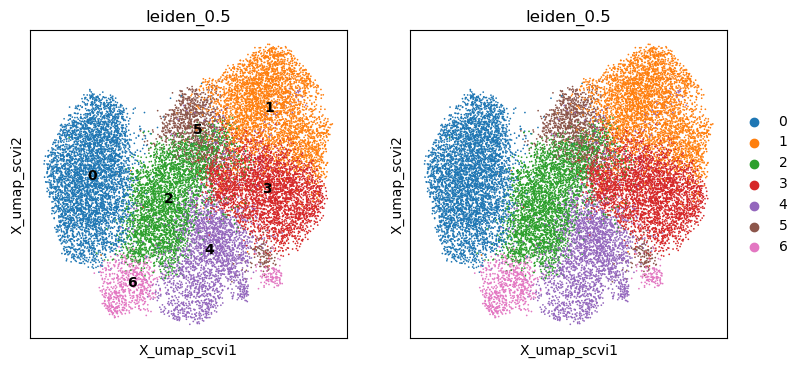

In [3]:
fig, ax = plt.subplots(1,2, figsize=(9,4))
sc.pl.embedding(rna, color=['leiden_0.5'], basis='X_umap_scvi', legend_loc='on data', ax=ax[0], show=False)
sc.pl.embedding(rna, color=['leiden_0.5'], basis='X_umap_scvi', ax=ax[1], show=False)
fig.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_scvi_umap.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_scvi_umap.png'), bbox_inches='tight')

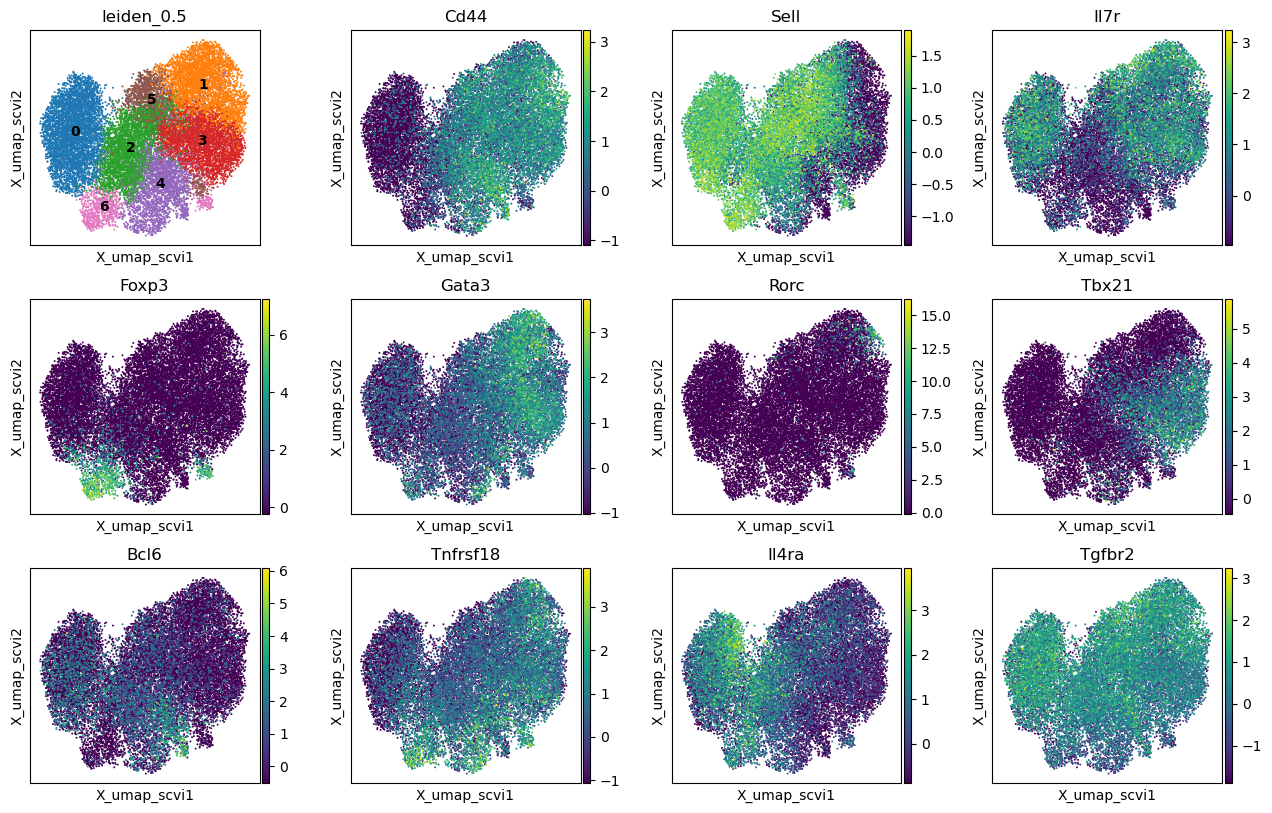

In [4]:
sc.pl.embedding(rna, color=['leiden_0.5','Cd44','Sell','Il7r','Foxp3','Gata3','Rorc','Tbx21','Bcl6','Tnfrsf18','Il4ra','Tgfbr2'],
                basis='X_umap_scvi', legend_loc='on data', size=8)

# Manually Curated Heatmap

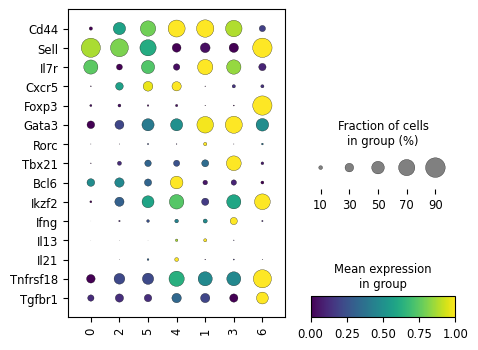

In [16]:
plot_genes = ['Cd44','Sell','Il7r','Cxcr5','Foxp3','Gata3','Rorc','Tbx21','Bcl6','Ikzf2','Ifng','Il13','Il21','Tnfrsf18','Tgfbr1']

order = ['0','2','5','4','1','3','6']
g = sc.pl.dotplot(rna, var_names=plot_genes,
                     groupby='leiden_0.5', standard_scale='var', dendrogram=False, swap_axes=True, cmap='viridis',
                     categories_order=order,
                     return_fig=True, figsize=(5,4))
g.savefig(f'{output_dir}/leiden0.5_manually_curated_dotplot.pdf')

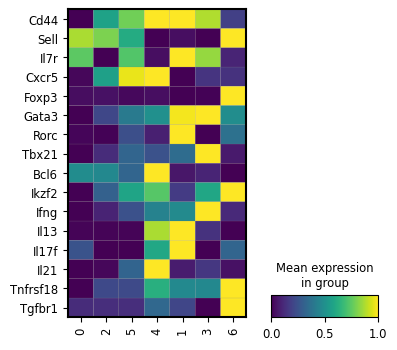

In [12]:
plot_genes = ['Cd44','Sell','Il7r','Cxcr5','Foxp3','Gata3','Rorc','Tbx21','Bcl6','Ikzf2','Ifng','Il13','Il17f','Il21','Tnfrsf18','Tgfbr1']

order = ['0','2','5','4','1','3','6']
g = sc.pl.matrixplot(rna, var_names=plot_genes,
                     groupby='leiden_0.5', standard_scale='var', dendrogram=False, swap_axes=True, cmap='viridis',
                     categories_order=order,
                     return_fig=True, figsize=(4,4))
g.savefig(f'{output_dir}/leiden0.5_manually_curated_matrixplot.pdf')

# Gata3 vs Ikzf2 (Helios) Expression, Clusters 1 and 3

In [ ]:
# define cutoffs for gata3 and helios
x_thresh = 0.4 #gata3
y_thresh = 0.4 #ikzf2

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


   Gata3+Ikzf2+  Gata3-Ikzf2+  Gata3+Ikzf2-  Gata3-Ikzf2-  n_cells
1     17.811705      3.689567     63.104326     15.394402    786.0
3     49.064171      9.759358     32.620321      8.556150    748.0
4     39.028777     21.582734     23.201439     16.187050    556.0


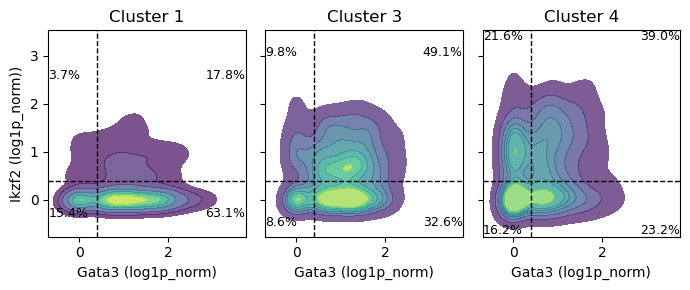

In [52]:
# subset to isotype and clusters of interest
clusters_of_interest = ['1','3','4']
mask = ((rna.obs['leiden_0.5'].isin(clusters_of_interest)) & (rna.obs['treatment'] == 'isotype'))

expr = pd.DataFrame(
    rna[mask, ['Gata3', 'Ikzf2']].layers['log1p_norm'].toarray(),
    columns=['Gata3', 'Ikzf2'],
    index=rna.obs_names[mask.values]
)
expr['cluster'] = rna.obs.loc[mask, 'leiden_0.5'].values

fig, axes = plt.subplots(1, 3, figsize=(7, 3), sharex=True, sharey=True)

quadrant_freqs = {}

for ax, cluster in zip(axes, clusters_of_interest):
    sub = expr[expr['cluster'] == cluster]
    color = f'C{clusters_of_interest.index(cluster)}'
    sns.kdeplot(data=sub, x='Gata3', y='Ikzf2', ax=ax, cmap='viridis', alpha=0.7, levels=8, linewidths=1, fill=True)
    ax.set_title(f'Cluster {cluster}')
    ax.set_xlabel('Gata3 (log1p_norm)')
    ax.set_ylabel('Ikzf2 (log1p_norm))')

    ax.axhline(y_thresh, color='black', linestyle='--', linewidth=1)
    ax.axvline(x_thresh, color='black', linestyle='--', linewidth=1)

    n = len(sub)
    q_pp = ((sub['Gata3'] >= x_thresh) & (sub['Ikzf2'] >= y_thresh)).sum() / n * 100
    q_np = ((sub['Gata3'] < x_thresh) & (sub['Ikzf2'] >= y_thresh)).sum() / n * 100
    q_pn = ((sub['Gata3'] >= x_thresh) & (sub['Ikzf2'] < y_thresh)).sum() / n * 100
    q_nn = ((sub['Gata3'] < x_thresh) & (sub['Ikzf2'] < y_thresh)).sum() / n * 100

    quadrant_freqs[cluster] = {
        'Gata3+Ikzf2+': q_pp,
        'Gata3-Ikzf2+': q_np,
        'Gata3+Ikzf2-': q_pn,
        'Gata3-Ikzf2-': q_nn,
        'n_cells': n
    }

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.text(xlim[1], ylim[1], f'{q_pp:.1f}%', ha='right', va='top', fontsize=9)
    ax.text(xlim[0], ylim[1], f'{q_np:.1f}%', ha='left', va='top', fontsize=9)
    ax.text(xlim[1], ylim[0], f'{q_pn:.1f}%', ha='right', va='bottom', fontsize=9)
    ax.text(xlim[0], ylim[0], f'{q_nn:.1f}%', ha='left', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'SIG19_DTR_iLN_Gata3_vs_Ikzf2_kde_cluster1_3.pdf'), bbox_inches='tight')

quadrant_df = pd.DataFrame(quadrant_freqs).T
print(quadrant_df)

   cluster    mouse       freq  n_cells
0        1   mouse1  13.450292      171
1        1  mouse13  18.888889       90
2        1  mouse17  14.492754       69
3        1  mouse21  20.930233      215
4        1   mouse5  13.953488      129
5        1   mouse9  24.107143      112
6        3   mouse1  41.538462      130
7        3  mouse13  37.096774       62
8        3  mouse17  49.019608       51
9        3  mouse21  52.000000      275
10       3   mouse5  51.401869      107
11       3   mouse9  54.471545      123


/tmp/ipykernel_170477/4190526407.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=freq_df, x='cluster', y='freq', ax=ax, palette=palette, fliersize=0)


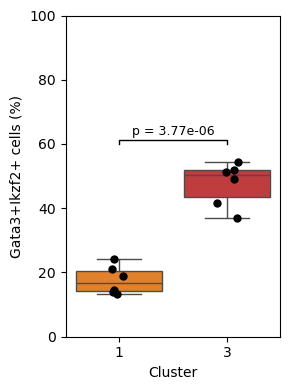

In [47]:
from scipy import stats
mask = ((rna.obs['leiden_0.5'].isin(['1','3'])) & (rna.obs['treatment'] == 'isotype'))

expr = pd.DataFrame(
    rna[mask, ['Gata3', 'Ikzf2']].layers['log1p_norm'].toarray(),
    columns=['Gata3', 'Ikzf2'],
    index=rna.obs_names[mask.values]
)
expr['cluster'] = rna.obs.loc[mask, 'leiden_0.5'].values.astype(str)
expr['mouse'] = rna.obs.loc[mask, 'mouse'].values.astype(str)

expr['double_pos'] = (expr['Gata3'] >= x_thresh) & (expr['Ikzf2'] >= y_thresh)

freq_df = (
    expr.groupby(['cluster', 'mouse'])['double_pos']
    .agg(freq='mean', n_cells='size')
    .reset_index()
)
freq_df['freq'] = freq_df['freq'] * 100

# map cluster labels to the colors AnnData already assigned them
all_categories = rna.obs['leiden_0.5'].cat.categories.tolist()
cluster_colors = dict(zip(all_categories, rna.uns['leiden_0.5_colors']))
palette = {c: cluster_colors[c] for c in clusters_of_interest}

fig, ax = plt.subplots(figsize=(3, 4))
sns.boxplot(data=freq_df, x='cluster', y='freq', ax=ax, palette=palette, fliersize=0)
sns.stripplot(data=freq_df, x='cluster', y='freq', ax=ax, color='black', size=6, jitter=True)
ax.set_xlabel('Cluster')
ax.set_ylabel('Gata3+Ikzf2+ cells (%)')

# t-test between cluster 1 and cluster 3
group1 = freq_df.loc[freq_df['cluster'] == clusters_of_interest[0], 'freq']
group2 = freq_df.loc[freq_df['cluster'] == clusters_of_interest[1], 'freq']
tstat, pval = stats.ttest_ind(group1, group2)

ymax = freq_df['freq'].max()
y_line = ymax * 1.1
ax.plot([0, 0, 1, 1], [y_line, y_line * 1.02, y_line * 1.02, y_line], color='black', linewidth=1)
ax.text(0.5, y_line * 1.03, f'p = {pval:.3g}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0,100)


plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'SIG19_DTR_iLN_Gata3_Ikzf2_doublepos_freq_boxplot_by_mouse.pdf'), bbox_inches='tight')
print(freq_df)

  comparison     raw_p    holm_p
0     (1, 3)  0.000105  0.000316
1     (1, 4)  0.007912  0.011868
2     (3, 4)  0.138328  0.138328


/tmp/ipykernel_170477/2844543508.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=freq_df, x='cluster', y='freq', ax=ax, order=clusters_of_interest, palette=palette, fliersize=0)


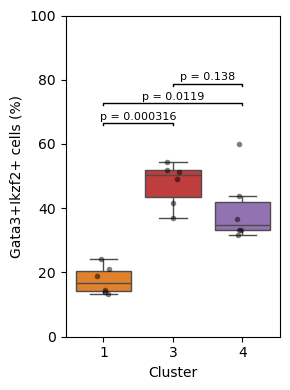

In [49]:
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# subset to isotype and clusters of interest
clusters_of_interest = ['1','3','4']
mask = ((rna.obs['leiden_0.5'].isin(clusters_of_interest)) & (rna.obs['treatment'] == 'isotype'))

expr = pd.DataFrame(
    rna[mask, ['Gata3', 'Ikzf2']].layers['log1p_norm'].toarray(),
    columns=['Gata3', 'Ikzf2'],
    index=rna.obs_names[mask.values]
)
expr['cluster'] = rna.obs.loc[mask, 'leiden_0.5'].values.astype(str)
expr['mouse'] = rna.obs.loc[mask, 'mouse'].values.astype(str)

expr['double_pos'] = (expr['Gata3'] >= x_thresh) & (expr['Ikzf2'] >= y_thresh)

freq_df = (
    expr.groupby(['cluster', 'mouse'])['double_pos']
    .agg(freq='mean', n_cells='size')
    .reset_index()
)
freq_df['freq'] = freq_df['freq'] * 100

# map cluster labels to the colors AnnData already assigned them
all_categories = rna.obs['leiden_0.5'].cat.categories.tolist()
cluster_colors = dict(zip(all_categories, rna.uns['leiden_0.5_colors']))
palette = {c: cluster_colors[c] for c in clusters_of_interest}

fig, ax = plt.subplots(figsize=(3, 4))
sns.boxplot(data=freq_df, x='cluster', y='freq', ax=ax, order=clusters_of_interest, palette=palette, fliersize=0)
sns.stripplot(data=freq_df, x='cluster', y='freq', ax=ax, order=clusters_of_interest, color='black', size=4, jitter=True , alpha=0.5)
ax.set_xlabel('Cluster')
ax.set_ylabel('Gata3+Ikzf2+ cells (%)')

# pairwise paired t-tests between all clusters, paired by mouse
paired = freq_df.pivot(index='mouse', columns='cluster', values='freq')[clusters_of_interest].dropna()

pairs = list(combinations(clusters_of_interest, 2))
raw_pvals = []
for c1, c2 in pairs:
    tstat, pval = stats.ttest_rel(paired[c1], paired[c2])
    raw_pvals.append(pval)

reject, pvals_corr, _, _ = multipletests(raw_pvals, method='fdr_bh')

# annotate brackets, stacked upward
ymax = freq_df['freq'].max()
y_start = ymax * 1.1
step = ymax * 0.1
cluster_pos = {c: i for i, c in enumerate(clusters_of_interest)}

for i, ((c1, c2), p_corr) in enumerate(zip(pairs, pvals_corr)):
    x1, x2 = cluster_pos[c1], cluster_pos[c2]
    y = y_start + i * step
    ax.plot([x1, x1, x2, x2], [y, y * 1.01, y * 1.01, y], color='black', linewidth=1)
    ax.text((x1 + x2) / 2, y * 1.015, f'p = {p_corr:.3g}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0,100)

plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'SIG19_DTR_iLN_Gata3_Ikzf2_doublepos_freq_boxplot_by_mouse_all_clusters.pdf'), bbox_inches='tight')
print(pd.DataFrame({'comparison': pairs, 'raw_p': raw_pvals, 'holm_p': pvals_corr}))

# Pseudobulk DEG Analysis with pyDESeq2 (Isotype-treated mice)

**Goal:** identify genes that differ between `leiden_0.5` clusters, restricted to isotype-treated mice, using mouse-level pseudobulk counts and a **paired design** (`~ mouse + condition`) that blocks on mouse to control for inter-animal variability.

**Plan:**
1. Subset to isotype-treated cells (6 mice) and confirm every mouse contributes enough cells to every cluster for pseudobulking.
2. **1-vs-rest marker genes:** for each cluster, pseudobulk "target cluster" and "rest" separately per mouse (6 paired samples x 2 conditions) using raw counts, fit pyDESeq2 with `~ mouse + comparison_group`, and extract markers via the cluster-vs-rest contrast.
3. **Cluster 1 vs Cluster 3:** pseudobulk cluster 1 and cluster 3 cells per mouse (6 paired samples x 2 clusters), fit pyDESeq2 with `~ mouse + leiden_0.5`, contrast cluster 3 vs cluster 1.
4. Visualize: number of markers per cluster, volcano plots (per-cluster and grid overview), and expression of top marker/DE genes across clusters.

Pairing by `mouse` is valid here because all 6 isotype mice have >=11 cells in every `leiden_0.5` cluster.

In [5]:
cluster_col = 'leiden_0.5'
sample_col = 'mouse'

iso = rna[rna.obs['treatment'] == 'isotype'].copy()
iso.obs[sample_col] = iso.obs[sample_col].astype(str).astype('category')
iso.obs[cluster_col] = iso.obs[cluster_col].astype(str).astype('category')

clusters = sorted(iso.obs[cluster_col].cat.categories, key=int)
print('Isotype mice:', iso.obs[sample_col].cat.categories.tolist())
print('Clusters:', clusters)

# sanity check: every mouse needs enough cells in every cluster to pseudobulk
cell_counts = pd.crosstab(iso.obs[sample_col], iso.obs[cluster_col])
cell_counts

Isotype mice: ['mouse1', 'mouse13', 'mouse17', 'mouse21', 'mouse5', 'mouse9']
Clusters: ['0', '1', '2', '3', '4', '5', '6']


leiden_0.5,0,1,2,3,4,5,6
mouse,,,,,,,
mouse1,134,171,133,130,108,44,18
mouse13,90,90,45,62,60,16,11
mouse17,68,69,49,51,30,26,16
mouse21,345,215,359,275,214,131,95
mouse5,245,129,122,107,63,45,31
mouse9,223,112,125,123,81,38,27


## 1-vs-rest marker genes (paired by mouse)

In [6]:
MIN_COUNT = 10
MIN_SAMPLES = 6

def run_pydeseq2_paired(adata, group_col, level_a, level_b, sample_col='mouse',
                         layer='counts', min_count=MIN_COUNT, min_samples=MIN_SAMPLES):
    """Paired pseudobulk pyDESeq2 contrast of level_a vs level_b, blocking on sample_col.

    Positive log_fc = higher in level_a.
    """
    ps_adata = pt.tl.PseudobulkSpace().compute(adata, target_col=sample_col, groups_col=group_col,
                                                layer_key=layer, mode='sum')
    ps_adata = ps_adata[ps_adata.obs[group_col].astype(str).isin([level_a, level_b])].copy()
    ps_adata.obs[group_col] = pd.Categorical(ps_adata.obs[group_col].astype(str),
                                              categories=[level_b, level_a])
    ps_adata.obs[sample_col] = ps_adata.obs[sample_col].astype(str).astype('category')

    # prefilter genes: require min_count reads in at least min_samples pseudobulk samples
    keep = (ps_adata.X >= min_count).sum(axis=0) >= min_samples
    ps_adata = ps_adata[:, keep].copy()

    model = pt.tl.PyDESeq2(adata=ps_adata, design=f'~ {sample_col} + {group_col}')
    model.fit()
    contrast = model.contrast(group_col, level_b, level_a)
    res = model.test_contrasts(contrast)
    return res.set_index('variable').drop(columns='contrast')


one_vs_rest_results = {}
for c in clusters:
    print(f'--- Cluster {c} vs rest ---')
    iso.obs['comparison_group'] = np.where(iso.obs[cluster_col].astype(str) == c, c, 'rest')
    res = run_pydeseq2_paired(iso, 'comparison_group', level_a=c, level_b='rest', sample_col=sample_col)
    res.to_csv(f'{output_dir}/leiden0.5_cluster{c}_vs_rest_pydeseq2.csv')
    one_vs_rest_results[c] = res

--- Cluster 0 vs rest ---
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.70 seconds.

Fitting dispersion trend curve...
... done in 0.14 seconds.

Fitting MAP dispersions...
... done in 0.94 seconds.

Fitting LFCs...
... done in 0.70 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 11.07 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 0. 0. 0. 1.]
         baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gnai3  436.038207       -0.421645  0.073516 -5.735418  9.727194e-09   
Narf   117.734515       -0.441553  0.132169 -3.340825  8.352979e-04   
Klf6   264.034355       -0.098480  0.093590 -1.052246  2.926866e-01   
Scmh1   17.647301        1.127934  0.310029  3.638160  2.745924e-04   
Cox5a  240.730461       -0.826534  0.103607 -7.977593  1.492146e-15   
...           ...             ...       ...       ...           ...   
Gpr52   10.540411       -2.390219  0.567811 -4.209535  2.558971e-05   
Shld3   43.972960        0.613932  0.191211  3.210751  1.323886e-03   
Tusc3  110.449306       -0.456624  0.139091 -3.282915  1.027395e-03   
Lin54   32.123303        0.501538  0.270655  1.853053  6.387473e-02   
Eppk1   12.016279        0.526251  0.382284  1.376598  1.686366e-01   

               padj  
Gnai3  6.208117e-08  
Narf   2.326699e-03  
Klf

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


...

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.70 seconds.

Fitting dispersion trend curve...
... done in 0.14 seconds.

Fitting MAP dispersions...
... done in 0.96 seconds.

Fitting LFCs...
... done in 0.84 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 0. 0. 0. 1.]
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gnai3  245.431620       -0.152181  0.131470 -1.157529  0.247056  0.673191
Narf    68.484296       -0.034386  0.211585 -0.162518  0.870898  0.974500
Klf6   141.413797       -0.039877  0.203227 -0.196221  0.844437  0.968877
Scmh1    8.134925        0.135475  0.602715  0.224774  0.822155  0.961287
Cox5a  144.841217       -0.174242  0.160188 -1.087739  0.276710  0.705074
...           ...             ...       ...       ...       ...       ...
Gpr52    8.178898        0.219174  0.550706  0.397988  0.690639  0.929739
Shld3   23.223127        0.373254  0.345674  1.079786  0.280237  0.708234
Tusc3   63.653957       -0.073376  0.212868 -0.344701  0.730319  0.939164
Lin54   20.532109        0.810085  0.388746  2.083840  0.037175  0.247916
Eppk1    5.032116       -0.476713  0.782717 -0.609049  0.542492  0.873420

[8998 rows x 6 columns]


... done in 4.36 seconds.



In [7]:
def volcano_plot(res, title, padj_thresh=0.05, lfc_thresh=1, top_n_label=15, ax=None):
    df = res.copy()
    df['neg_log10_padj'] = -np.log10(df['adj_p_value'].clip(lower=1e-300))
    df['sig'] = 'ns'
    df.loc[(df['adj_p_value'] < padj_thresh) & (df['log_fc'] > lfc_thresh), 'sig'] = 'up'
    df.loc[(df['adj_p_value'] < padj_thresh) & (df['log_fc'] < -lfc_thresh), 'sig'] = 'down'

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    palette = {'ns': 'lightgray', 'up': 'firebrick', 'down': 'steelblue'}
    sns.scatterplot(data=df, x='log_fc', y='neg_log10_padj', hue='sig', palette=palette,
                     s=10, linewidth=0, ax=ax, legend=False)
    ax.axhline(-np.log10(padj_thresh), linestyle='--', color='gray', linewidth=0.5)
    ax.axvline(lfc_thresh, linestyle='--', color='gray', linewidth=0.5)
    ax.axvline(-lfc_thresh, linestyle='--', color='gray', linewidth=0.5)

    n_label = max(top_n_label // 2, 1)
    label_genes = pd.concat([
        df[df['sig'] == 'up'].sort_values('adj_p_value').head(n_label),
        df[df['sig'] == 'down'].sort_values('adj_p_value').head(n_label),
    ])
    for gene, row in label_genes.iterrows():
        ax.text(row['log_fc'], row['neg_log10_padj'], gene, fontsize=6)

    ax.set_xlabel('log2 fold change')
    ax.set_ylabel('-log10(adj p-value)')
    ax.set_title(title, fontsize=9)
    return ax


SIG_PADJ = 0.05
SIG_LFC = 1

marker_summary = []
top_markers = {}
for c, res in one_vs_rest_results.items():
    sig = res[(res['adj_p_value'] < SIG_PADJ) & (res['log_fc'] > SIG_LFC)].sort_values('log_fc', ascending=False)
    top_markers[c] = sig.head(15).index.tolist()
    marker_summary.append({'cluster': c, 'n_markers': sig.shape[0]})

marker_summary = pd.DataFrame(marker_summary)
marker_summary.to_csv(f'{output_dir}/leiden0.5_1vsrest_nmarkers_summary.csv', index=False)
marker_summary

,cluster,n_markers
0,0,404
1,1,257
2,2,69
3,3,226
4,4,282
5,5,43
6,6,159


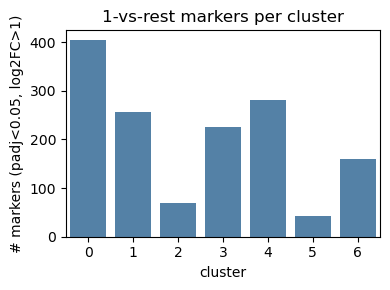

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(data=marker_summary, x='cluster', y='n_markers', order=clusters, ax=ax, color='steelblue')
ax.set_ylabel(f'# markers (padj<{SIG_PADJ}, log2FC>{SIG_LFC})')
ax.set_title('1-vs-rest markers per cluster')
plt.tight_layout()
plt.savefig(f'{output_dir}/leiden0.5_1vsrest_nmarkers_barplot.pdf')
plt.show()

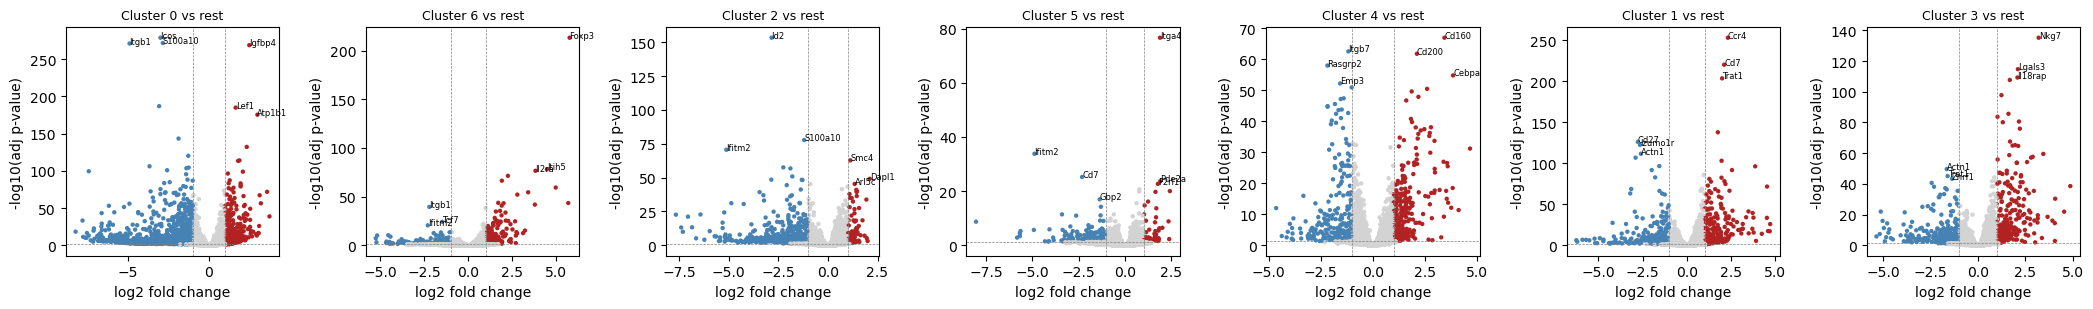

In [9]:
order = ['0', '6', '2', '5', '4', '1', '3']

fig, axes = plt.subplots(1, len(clusters), figsize=(3 * len(clusters), 3.2))
for ax, c in zip(axes, order):
    volcano_plot(one_vs_rest_results[c], f'Cluster {c} vs rest', top_n_label=6, ax=ax)
plt.tight_layout()
plt.savefig(f'{output_dir}/leiden0.5_1vsrest_volcano_grid.pdf')
plt.show()

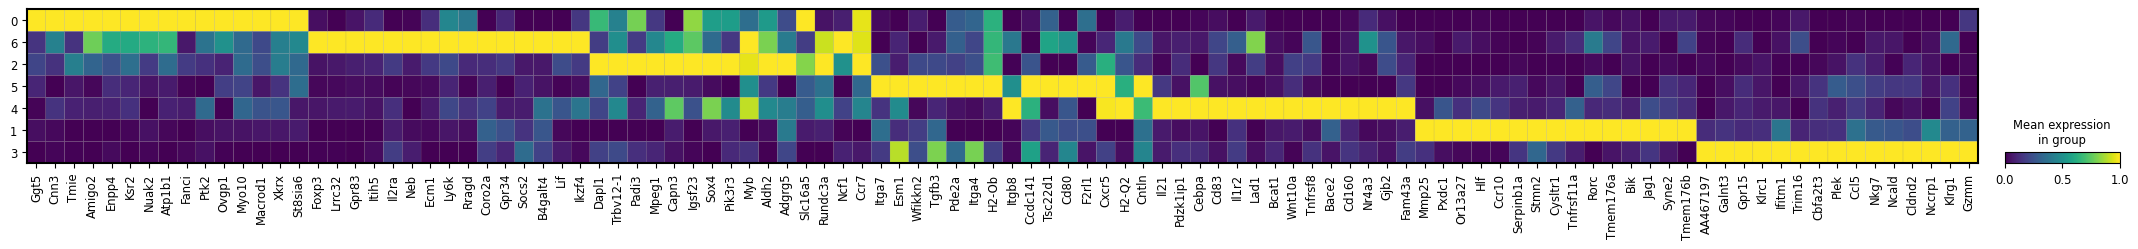

In [10]:
# top marker genes per cluster (deduplicated, ordered by cluster)
top_gene_list = []
for c in order:
    for g in top_markers[c]:
        if g not in top_gene_list:
            top_gene_list.append(g)

g = sc.pl.matrixplot(iso, var_names=top_gene_list, groupby=cluster_col,
                   categories_order=order, standard_scale='var', cmap='viridis',
                   return_fig=True, figsize=(len(top_gene_list) * 0.25 + 1, 2))
g.savefig(f'{output_dir}/leiden0.5_1vsrest_top10_markers_matrixplot.pdf')

## Cluster 1 vs Cluster 3 (direct, paired by mouse)

Contrast: cluster 3 vs cluster 1, so positive `log_fc` = higher in cluster 3.

In [11]:
c3_vs_c1 = run_pydeseq2_paired(iso, cluster_col, level_a='3', level_b='1', sample_col=sample_col)
c3_vs_c1.to_csv(f'{output_dir}/leiden0.5_cluster3_vs_cluster1_pydeseq2.csv')
c3_vs_c1.sort_values('adj_p_value').head(15)

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.51 seconds.

Fitting dispersion trend curve...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.83 seconds.

Fitting LFCs...
... done in 0.58 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 0. 0. 0. 1.]
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gnai3     322.645264        0.021396  0.091516  0.233795  0.815144  0.977572
Narf       83.889030       -0.065295  0.158974 -0.410729  0.681271  0.954395
Klf6      204.385897       -0.183976  0.104900 -1.753815  0.079462  0.426603
Cox5a     218.137543       -0.011465  0.101475 -0.112988  0.910040  0.986612
Xpo6      173.598822       -0.024597  0.112830 -0.218000  0.827429  0.978875
...              ...             ...       ...       ...       ...       ...
Itprip     21.816745       -0.143710  0.285100 -0.504070  0.614212  0.935279
Tmem179b   97.023248        0.198054  0.149062  1.328671  0.183956  0.654747
Shld3      18.481920        0.353734  0.332580  1.063605  0.287508  0.774037
Tusc3      69.463664        0.500933  0.161671  3.098461  0.001945  0.026765
Lin54      15.910750       -0.737170  0.336645 -2.189754  0.028542  0.22138

... done in 8.92 seconds.



,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value
variable,,,,,,
Trat1,338.339200,-2.667101,0.119936,-22.237774,1.481246e-109,1.216696e-105
Ccr4,379.546421,-2.244185,0.112057,-20.027170,3.192945e-89,1.311343e-85
Nav2,87.210549,-2.952008,0.200488,-14.724110,4.513716e-49,1.235855e-45
Arap2,183.692821,1.624002,0.114461,14.188244,1.083382e-45,2.224724e-42
Hopx,536.857502,1.149699,0.083490,13.770461,3.837568e-43,6.304357e-40
Gpr183,186.500395,1.385673,0.118859,11.658086,2.086811e-31,2.481009e-28
Znrf1,206.567717,-1.355178,0.116255,-11.656970,2.114325e-31,2.481009e-28
Rnf149,174.055622,-1.400870,0.124445,-11.256924,2.141028e-29,2.198300e-26
Cysltr1,57.994679,-2.762832,0.245762,-11.241881,2.539134e-29,2.317383e-26


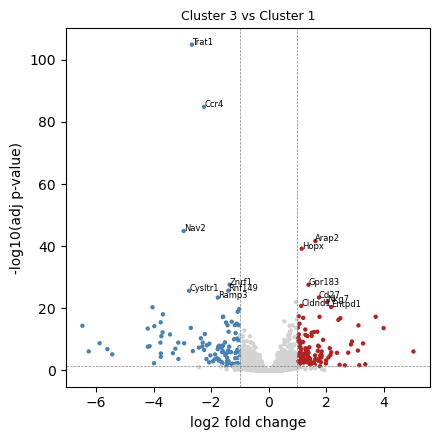

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
volcano_plot(c3_vs_c1, 'Cluster 3 vs Cluster 1', ax=ax)
plt.tight_layout()
plt.savefig(f'{output_dir}/leiden0.5_cluster3_vs_cluster1_volcano.pdf')
plt.show()

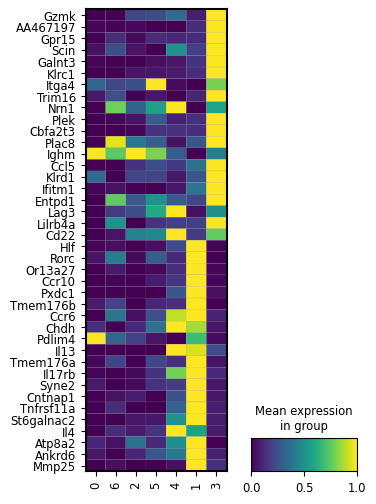

In [13]:
# top genes up in cluster 3 and top genes up in cluster 1, shown across all clusters for context
top_c3_c1_genes = pd.concat([
    c3_vs_c1[(c3_vs_c1['adj_p_value'] < SIG_PADJ) & (c3_vs_c1['log_fc'] > SIG_LFC)].sort_values('log_fc', ascending=False).head(20),
    c3_vs_c1[(c3_vs_c1['adj_p_value'] < SIG_PADJ) & (c3_vs_c1['log_fc'] < -SIG_LFC)].sort_values('log_fc').head(20),
]).index.tolist()

g = sc.pl.matrixplot(iso, var_names=top_c3_c1_genes, groupby=cluster_col,
                      standard_scale='var', dendrogram=False, swap_axes=True, cmap='viridis',
                      categories_order=order, return_fig=True, figsize=(3.5, 6))
g.savefig(f'{output_dir}/leiden0.5_cluster3_vs_cluster1_top_genes_matrixplot.pdf')